## Install Required Libraries

In [3]:
!pip install transformers datasets torchvision pillow -q

import os
import pandas as pd
import torch
import torch.nn as nn
import requests
import torchvision.models as models
from PIL import Image
from io import BytesIO
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, BertModel
from torchvision.models import resnet50
from sklearn.preprocessing import MultiLabelBinarizer

## Load and Clean Dataset

In [4]:
df = pd.read_csv('tmdb_text_image_only finall .csv')

df = df[['overview_enhanced','poster_path','label']]
df = df.dropna().drop_duplicates()

##  Encode Labels

In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'].astype(str))


## Train / Val / Test Split

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))


3936 844 844


## Image Loader

In [7]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def load_image(poster_path):
    try:
        path = 'images/' + poster_path.replace('/', '')
        img = Image.open(path).convert('RGB')
        return image_transform(img)
    except:
        return None

## Tokenizer (BERT)

In [8]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(text):
    return tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

##  Custom Multimodal Dataset

In [9]:
class TMDBDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        tokens = tokenize(row['overview_enhanced'])

        image = load_image(row['poster_path'])

        if image is None:
            image = torch.randn(3,224,224) * 0.1

        return {
            'input_ids': tokens['input_ids'].squeeze(0),
            'attention_mask': tokens['attention_mask'].squeeze(0),
            'image': image,
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

##   DataLoader

In [10]:
train_dataset = TMDBDataset(train_df)
val_dataset   = TMDBDataset(val_df)
test_dataset  = TMDBDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)
test_loader  = DataLoader(test_dataset, batch_size=8)


##  CNN + BERT Multimodal Model

In [11]:
class MultimodalModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.bert = BertModel.from_pretrained('bert-base-uncased')

        self.cnn = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, 512)

        # freeze CNN (IMPORTANT FIX)
        for param in self.cnn.parameters():
            param.requires_grad = False

        self.fc1 = nn.Linear(768 + 512, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, image):

        text_feat = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).pooler_output

        img_feat = self.cnn(image)

        combined = torch.cat((text_feat, img_feat), dim=1)

        x = self.dropout(self.fc1(combined))
        return self.fc2(x)


##  Training Setup

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MultimodalModel(num_classes=df['label'].nunique()).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.2MB/s]


##  Training Loop
Recording Training Loss and Accuracy

In [13]:
epochs = 3

train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    train_preds, train_labels = [], []

    for batch in train_loader:

        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        img = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(ids, mask, img)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_loss = total_loss / len(train_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")



Epoch 1
Train Loss: 0.1556 | Train Acc: 0.9472

Epoch 2
Train Loss: 0.0398 | Train Acc: 0.9868

Epoch 3
Train Loss: 0.0130 | Train Acc: 0.9954


## Validation

In [14]:
    model.eval()

    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:

            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            img = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(ids, mask, img)
            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_accuracies.append(val_acc)

    print(f"Validation Acc: {val_acc:.4f}")

Validation Acc: 0.9870


## Model Evaluation on Test Set


In [15]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:

        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        img = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(ids, mask, img)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nTEST RESULTS")
print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average='weighted'))
print("Recall   :", recall_score(all_labels, all_preds, average='weighted'))
print("F1 Score :", f1_score(all_labels, all_preds, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))


TEST RESULTS
Accuracy : 0.9798578199052133
Precision: 0.9799069456869649
Recall   : 0.9798578199052133
F1 Score : 0.9798433120132454

Classification Report:

              precision    recall  f1-score   support

      Action       0.98      0.99      0.99       338
      Comedy       0.99      0.97      0.98       280
      Horror       0.97      0.98      0.97       226

    accuracy                           0.98       844
   macro avg       0.98      0.98      0.98       844
weighted avg       0.98      0.98      0.98       844



## Training Curves (Loss & Accuracy)

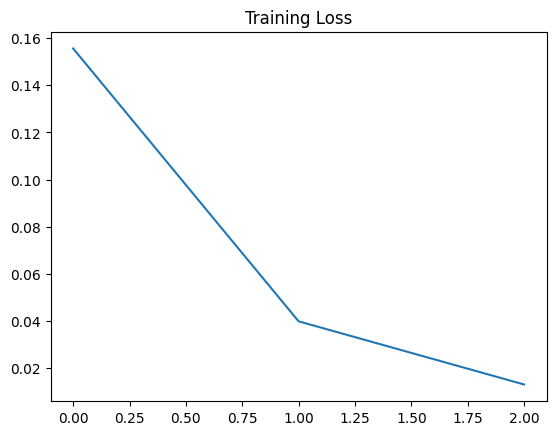

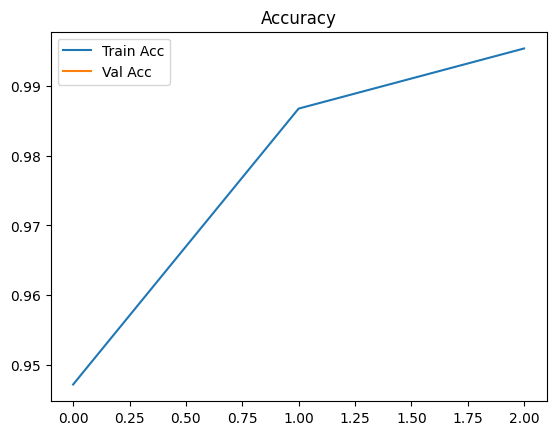

In [16]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.title("Accuracy")
plt.legend()
plt.show()

##  Confusion Matrix Visualization


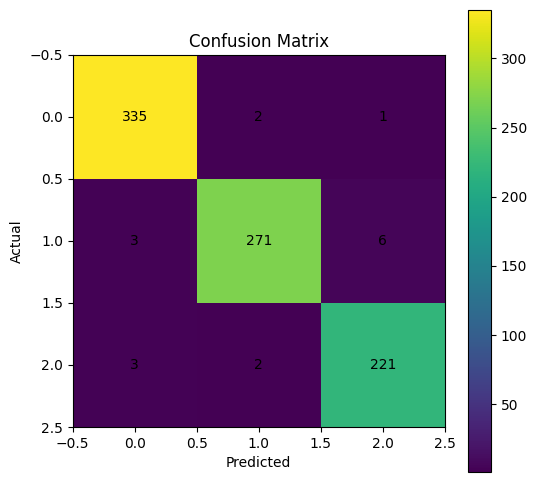

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center')

plt.colorbar()
plt.show()

## Data Leakage Check

In [18]:
train_set = set(train_df['poster_path'])
test_set = set(test_df['poster_path'])

print(len(train_set.intersection(test_set)))

0
